In [126]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader,TensorDataset
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report


In [127]:
data = pd.read_csv('train.csv')
data.insert(0, 'bias', 1)
# only getting images with labels equal to zeros or ones for logistic regression
binary_data = data[(data['label'] == 0) | (data['label'] == 1)]

In [128]:
targets = binary_data['label'].values
x = binary_data.drop('label',axis = 1).values

In [129]:
#scaling all pixels to be between 0 and 1 except the bias
x[:,1:] = x[:,1:] / 255.0

In [130]:
x_train, x_rest, t_train, t_rest = train_test_split(x, targets, train_size = 0.6, random_state = 42, shuffle = True, stratify = targets)
x_val, x_test, t_val, t_test = train_test_split(x_rest, t_rest, train_size = 0.5, random_state = 42, shuffle = True, stratify = t_rest)

In [131]:
# creating our tensors
tensor_x_train = torch.from_numpy(x_train)
tensor_t_train = torch.from_numpy(t_train)
tensor_x_val = torch.from_numpy(x_val)
tensor_t_val = torch.from_numpy(t_val)
tensor_x_test = torch.from_numpy(x_test)
tensor_t_test = torch.from_numpy(t_test)

tensor_x_train = tensor_x_train.T         #as we want each col to represent one sample
tensor_x_val = tensor_x_val.T
tensor_x_test = tensor_x_test.T

no_of_samples = tensor_x_train.shape[1]
no_of_features = tensor_x_train.shape[0]

In [132]:
def sigmoid(z):
    y = 1 / ( 1 + torch.exp(-z))
    return y

In [133]:
def binary_cross_entropy_loss(y,t):
    loss = ( -t * torch.log(y) ) - ( (1-t) * torch.log((1-y)) )
    overall_loss = loss.mean()
    return overall_loss


In [134]:
def calculate_derivative(w):
    derivative = torch.zeros((no_of_features,1))
    for i in range(no_of_samples):
        col = tensor_x_train[:,i]
        col = col.reshape(-1,1)
        tmp = w.T
        z = (tmp @ col)
        y = sigmoid(z)
        derivative = derivative + ( y - tensor_t_train[i]) * col
    return derivative

In [135]:
def calculate_derivative_vectorized(w,x,t):
    y = sigmoid(w.T @ x)
    derivative = x @ (y - t).T
    return derivative

In [136]:
def gradient_descent(alpha, batch_size, tensor_x, tensor_t):
    train_dataset = TensorDataset(tensor_x.T, tensor_t)
    loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
    losses = []
    accuracies = []
    torch.set_default_dtype(torch.float64)
    w = torch.zeros((no_of_features,1))
    tolerance = 0.0001
    epochs = 1000

    for _ in range(epochs):
        correct = 0
        iteration_loss = 0
        for X_batch, t_batch in loader:
            X_batch = X_batch.to(torch.float64)
            t_batch = t_batch.to(torch.float64)
            # to calculate the dervitaive
            derivative = calculate_derivative_vectorized(w,X_batch.T,t_batch)
            w = w - ( alpha*derivative / X_batch.shape[1] )
            y = sigmoid(w.T @ X_batch.T)
            iteration_loss += binary_cross_entropy_loss(y,t_batch)
            preds = (y >= 0.5).float()
            correct += (preds == t_batch).sum().item()
        losses.append(iteration_loss/len(loader))
        accuracies.append(correct/tensor_t.shape[0])
        if np.linalg.norm(derivative) < tolerance:
            # print('waslt le el tolerance')
            break

    return losses, accuracies, w

In [137]:
# gradient descent call with traning data
losses_t,acc_t,_ = gradient_descent(0.01,64, tensor_x_train, tensor_t_train)
# gradient descent call with validation data
losses_v, acc_v, _ = gradient_descent(0.01, 64, tensor_x_val, tensor_t_val)

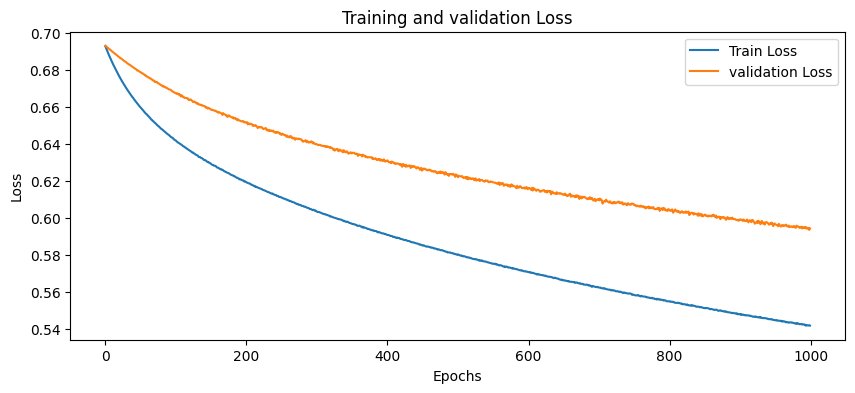

In [138]:
plt.figure(figsize=(10,4))
plt.plot(losses_t, label='Train Loss')
plt.plot(losses_v, label='validation Loss')
plt.title('Training and validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

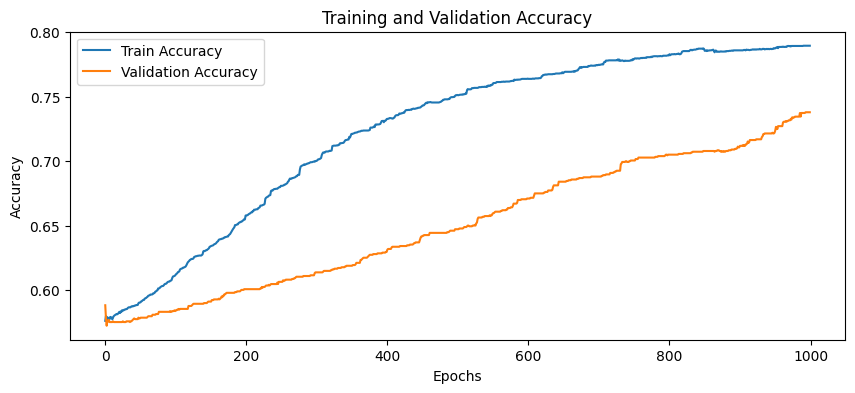

In [139]:
plt.figure(figsize=(10,4))
plt.plot(acc_t, label='Train Accuracy')
plt.plot(acc_v, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

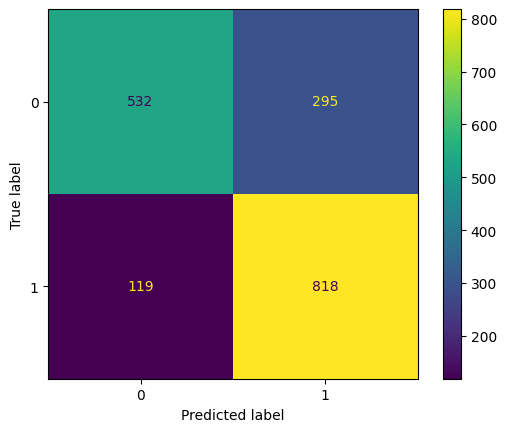

Final Test Accuracy: 76.53061224489795%


In [140]:
_,_,w = gradient_descent(0.01, 64, tensor_x_train, tensor_t_train)

#saving the model's traning progress
torch.save(w, "logistic_model_checkpoint.pth")

#calculating confusion matrix
y_test_pred = sigmoid(w.T @ tensor_x_test.to(torch.float64))
y_test_pred_labels = (y_test_pred >= 0.5).float().view(-1)

cm = confusion_matrix(tensor_t_test.numpy(), y_test_pred_labels.numpy())
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

correct = (y_test_pred_labels == tensor_t_test).sum().item()
total = tensor_t_test.shape[0]
test_accuracy = correct / total
print(f"Final Test Accuracy: {test_accuracy*100}%")


In [141]:
# tuning for gd in logistic
batch_sizes = [16, 32, 64, 128]
losses_b = []
losses_a = []
for batch_size in batch_sizes:
    loss,_,_ = gradient_descent(0.01, batch_size, tensor_x_val, tensor_t_val)
    losses_b.append(loss[-1])
print(f'best batch_size = {batch_sizes[np.argmin(losses_b)]}')
alpha_values = [0.001, 0.01, 0.1, 1.0]
for alpha in alpha_values:
    loss,_,_ = gradient_descent(alpha, 64, tensor_x_val, tensor_t_val)
    losses_a.append(loss[-1])
print(f'best alpha = {alpha_values[np.argmin(losses_a)]}')

best batch_size = 128
best alpha = 1.0


In [142]:
#........................... softmax .......................

targets = data['label'].values
x =  data.drop('label',axis = 1).values
x[:,1:] = x[:,1:] / 255.0

In [143]:
x_train, x_rest, t_train, t_rest = train_test_split(x, targets, train_size = 0.6, random_state = 42, shuffle = True, stratify = targets)
x_val, x_test, t_val, t_test = train_test_split(x_rest, t_rest, train_size = 0.5, random_state = 42, shuffle = True, stratify = t_rest)

In [144]:
tensor_x_train = torch.from_numpy(x_train)
tensor_t_train = torch.from_numpy(t_train)
tensor_x_val = torch.from_numpy(x_val)
tensor_t_val = torch.from_numpy(t_val)
tensor_x_test = torch.from_numpy(x_test)
tensor_t_test = torch.from_numpy(t_test)

tensor_x_train = tensor_x_train.T         # as we want each col to represent one sample
tensor_x_val = tensor_x_val.T
tensor_x_test = tensor_x_test.T

In [145]:
def cross_entropy_loss(t,y):
    epsilon = 1e-12
    y = torch.clamp(y, epsilon, 1. - epsilon)
    l = -torch.sum(t * torch.log(y)) / y.shape[1]  # average over samples
    return l

In [146]:
#z = Wx
def softmax(z):
    z = z - torch.max(z, dim=0, keepdim=True).values  # numerical stability
    exp_z = torch.exp(z)
    return exp_z / torch.sum(exp_z, dim=0, keepdim=True)


In [147]:
def calculate_derivative_vectorized_sm(w,x,t):
    y = softmax(w @ x)
    derivative =  (y - t) @ x.T
    return derivative

In [148]:
class SoftmaxRegression(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.linear(x)   # raw logits (softmax inside loss)


In [149]:
def gd_multiclass(alpha,batch_size,tensor_x,tensor_t):
    train_dataset = TensorDataset(tensor_x.T, tensor_t)
    loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
    losses_m = []
    accuracies_m = []
    losses_pyt = []
    accuracies_pyt = []
    torch.set_default_dtype(torch.float64)
    w = torch.zeros((10,tensor_x.shape[0]))     # 10 --> as we have 10 classes to choose from
    tolerance = 0.0001
    epochs = 100

    # model + loss + optimizer (built in softmax)
    model = SoftmaxRegression(tensor_x_train.shape[0], 10)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=alpha)

    for _ in range(epochs):
        model.train()
        correct_m = 0
        iteration_loss_m = 0
        correct_pyt = 0
        iteration_loss_pyt = 0
        for X_batch, t_batch in loader:
          # manual softmax
            X_batch = X_batch.to(torch.float64)
            t_onehot = F.one_hot(t_batch, num_classes=10).T.to(torch.float64)
            # to calculate the dervitaive
            derivative = calculate_derivative_vectorized_sm(w,X_batch.T,t_onehot)
            w = w - ( alpha*derivative / X_batch.shape[1] )
            y = softmax(w @ X_batch.T)
            iteration_loss_m += cross_entropy_loss(t_onehot,y)
            preds = torch.argmax(y, dim=0)
            correct_m += (preds == t_batch).sum().item()
          # pytorch's built in softmax
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, t_batch)
            loss.backward()
            optimizer.step()
            iteration_loss_pyt += loss.item()
            predicted = torch.argmax(outputs, dim=1)
            correct_pyt += (predicted == t_batch).sum().item()
        losses_m.append(iteration_loss_m/len(loader))
        accuracies_m.append(correct_m/tensor_t.shape[0])
        losses_pyt.append(iteration_loss_pyt/len(loader))
        accuracies_pyt.append(correct_pyt/tensor_t.shape[0])
        if np.linalg.norm(derivative) < tolerance:
            break
    torch.save(model.state_dict(), "model_checkpoint_softmax.pth")
    return losses_m,accuracies_m,losses_pyt,accuracies_pyt,w

In [150]:
losses_t, acc_t, loss_pyt_t,acc_pyt_t,_ = gd_multiclass(0.1,64,tensor_x_train,tensor_t_train)
losses_v, acc_v, loss_pyt_v,acc_pyt_v,_ = gd_multiclass(0.1,64,tensor_x_val,tensor_t_val)


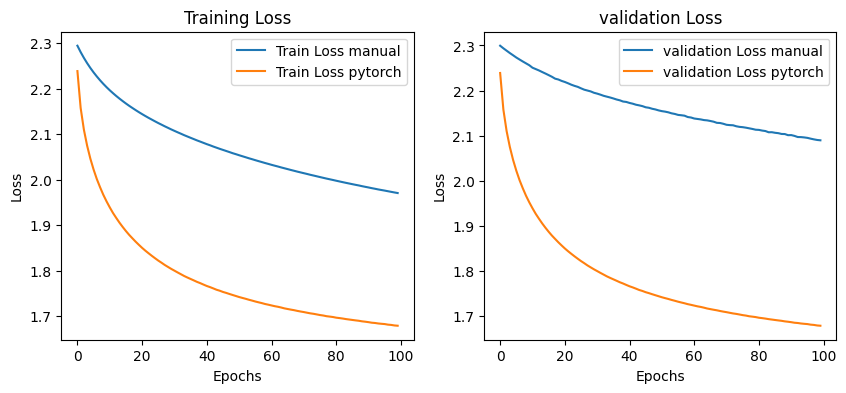

In [151]:
plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)
plt.plot(losses_t, label='Train Loss manual')
plt.plot(loss_pyt_t, label='Train Loss pytorch')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(losses_v, label='validation Loss manual')
plt.plot(loss_pyt_t, label='validation Loss pytorch')
plt.title('validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

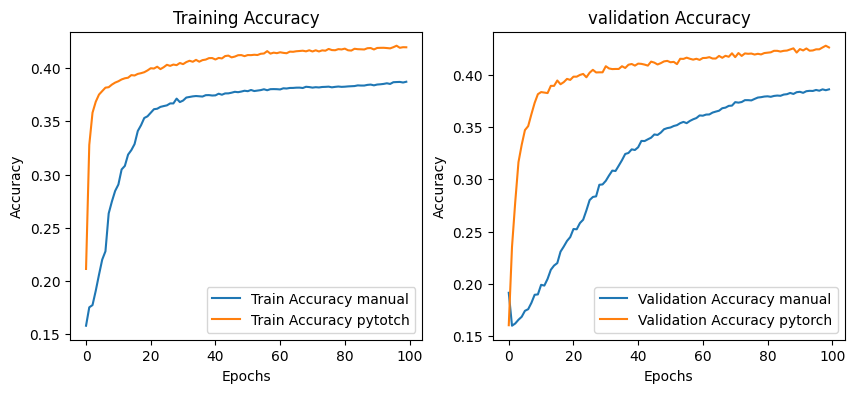

In [152]:
plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)
plt.plot(acc_t, label='Train Accuracy manual')
plt.plot(acc_pyt_t, label='Train Accuracy pytotch')
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(acc_v, label='Validation Accuracy manual')
plt.plot(acc_pyt_v, label='Validation Accuracy pytorch')
plt.title('validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

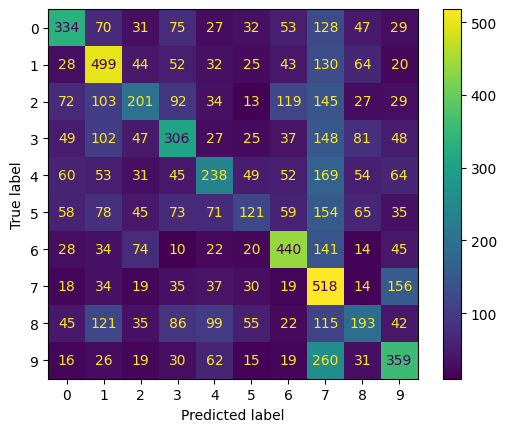

Final Test Accuracy: 38.20%
              precision    recall  f1-score   support

           0      0.472     0.404     0.435       826
           1      0.446     0.533     0.485       937
           2      0.368     0.241     0.291       835
           3      0.381     0.352     0.366       870
           4      0.367     0.292     0.325       815
           5      0.314     0.159     0.212       759
           6      0.510     0.531     0.520       828
           7      0.271     0.589     0.372       880
           8      0.327     0.237     0.275       813
           9      0.434     0.429     0.431       837

    accuracy                          0.382      8400
   macro avg      0.389     0.377     0.371      8400
weighted avg      0.390     0.382     0.374      8400



In [153]:
_,_,_,_,w = gd_multiclass(1,64,tensor_x_train,tensor_t_train)
y_test_pred = softmax(w @ tensor_x_test.to(torch.float64))
y_test_pred_labels = torch.argmax(y_test_pred, dim=0)
cm = confusion_matrix(tensor_t_test.numpy(), y_test_pred_labels.numpy())
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()
correct = (y_test_pred_labels == tensor_t_test).sum().item()
total = tensor_t_test.size(0)
test_accuracy = correct / total
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")
print(classification_report(
    tensor_t_test.numpy(),
    y_test_pred_labels.numpy(),
    digits=3
))


